/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Model,Stage,RMSE (mean),95% CI,MAE,R2,Pearson r
0,OLS,Baseline (Metadata Only),12.817354,"[10.95, 14.90]",10.306695,0.217600,0.486483
1,OLS,Baseline (CpG Only),7.142080,"[4.96, 9.46]",4.642453,0.747522,0.898299
2,OLS,Baseline (Combined),7.113072,"[4.96, 9.44]",4.626398,0.749501,0.898790
3,ElasticNet,Baseline (Defaults),5.832315,"[4.63, 7.29]",4.269786,0.833767,0.916086
4,SVR,Baseline (Defaults),9.498871,"[7.89, 11.29]",7.332972,0.571053,0.804409
5,Bayesian Ridge,Baseline (Defaults),6.309351,"[4.58, 8.44]",4.117792,0.802882,0.912598


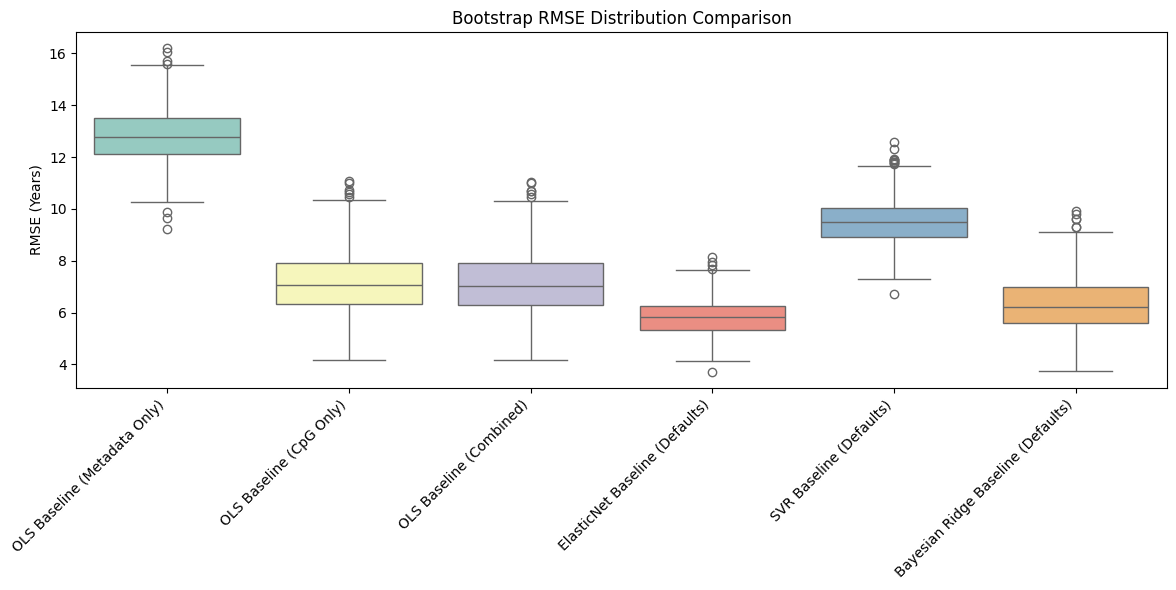

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Get directory of the current notebook and navigate to src
sys.path.append('../src/')

from functions import bootstrap_eval, load_dataset, split_data, get_preprocessing_pipeline

# --- Setup: Load Data and Create Feature Matrices ---
# Load and split data
df_dev = load_dataset('/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/data/development_data.csv')
train_df, val_df = split_data(df_dev, target_col='age', test_size=0.2, seed=42)

# Extract target variables
y_train = train_df['age'].values
y_val = val_df['age'].values

# Identify feature columns
cpg_cols = [col for col in df_dev.columns if col.startswith('cg')]
meta_cols = ['sex', 'ethnicity']

# Initialize and fit preprocessing pipeline
preprocessor = get_preprocessing_pipeline(cpg_cols, meta_cols)
X_train_all = preprocessor.fit_transform(train_df)
X_val_all = preprocessor.transform(val_df)

# Get feature names for subsetting
feature_names = preprocessor.get_feature_names_out()

def get_subsets(X, names):
    # CpG features start with 'num__cg' due to pipeline naming
    cpg_idx = [i for i, n in enumerate(names) if 'cg' in n]
    meta_idx = [i for i, n in enumerate(names) if 'cat__' in n]
    return X[:, meta_idx], X[:, cpg_idx], X

# Construct the matrices required for Task 2 baselines 
X_train_meta, X_train_cpg, X_train_combined = get_subsets(X_train_all, feature_names)
X_val_meta, X_val_cpg, X_val_combined = get_subsets(X_val_all, feature_names)

# --- Task 2.1: OLS Baseline ---
feature_sets = {
    'Metadata Only': (X_train_meta, X_val_meta),
    'CpG Only': (X_train_cpg, X_val_cpg),
    'Combined': (X_train_combined, X_val_combined)
}

ols_results = []
for name, (X_tr, X_val) in feature_sets.items():
    model = LinearRegression().fit(X_tr, y_train)
    preds = model.predict(X_val)
    boot_metrics = bootstrap_eval(y_val, preds)
    
    ols_results.append({
        'Model': 'OLS', 'Stage': f'Baseline ({name})',
        'RMSE (mean)': boot_metrics['RMSE']['mean'],
        '95% CI': f"[{boot_metrics['RMSE']['lo']:.2f}, {boot_metrics['RMSE']['hi']:.2f}]",
        'MAE': boot_metrics['MAE']['mean'],
        'R2': boot_metrics['R2']['mean'],
        'Pearson r': boot_metrics['Pearson_r']['mean'],
        'RMSE_raw': boot_metrics['RMSE']['raw'] # for boxplots
    })

# --- Task 2.2: Default Models (CpG Only) ---
default_models = {
    'ElasticNet': ElasticNet(random_state=42),
    'SVR': SVR(kernel='rbf'),
    'Bayesian Ridge': BayesianRidge()
}

advanced_results = []
for name, model in default_models.items():
    model.fit(X_train_cpg, y_train)
    preds = model.predict(X_val_cpg)
    boot_metrics = bootstrap_eval(y_val, preds)
    
    advanced_results.append({
        'Model': name, 'Stage': 'Baseline (Defaults)',
        'RMSE (mean)': boot_metrics['RMSE']['mean'],
        '95% CI': f"[{boot_metrics['RMSE']['lo']:.2f}, {boot_metrics['RMSE']['hi']:.2f}]",
        'MAE': boot_metrics['MAE']['mean'],
        'R2': boot_metrics['R2']['mean'],
        'Pearson r': boot_metrics['Pearson_r']['mean'],
        'RMSE_raw': boot_metrics['RMSE']['raw']
    })

# --- Deliverable: Performance Table ---
full_task2_results = pd.DataFrame(ols_results + advanced_results)
display(full_task2_results.drop(columns='RMSE_raw'))

# --- Deliverable: Bootstrap Boxplots ---
plt.figure(figsize=(12, 6))
plot_data = pd.DataFrame({res['Model'] + " " + res['Stage']: res['RMSE_raw'] for res in ols_results + advanced_results})
sns.boxplot(data=plot_data, palette="Set3")
plt.xticks(rotation=45, ha='right')
plt.title('Bootstrap RMSE Distribution Comparison')
plt.ylabel('RMSE (Years)')
plt.tight_layout()
plt.savefig('../figures/task2_bootstrap_boxplots.png')

In [2]:
# %%
!pip install mrmr_selection matplotlib_venn
from mrmr import mrmr_regression
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src/')
from functions import stability_selection, evaluate_proxy_model

Running Stability Selection...
Number of stable features selected: 185


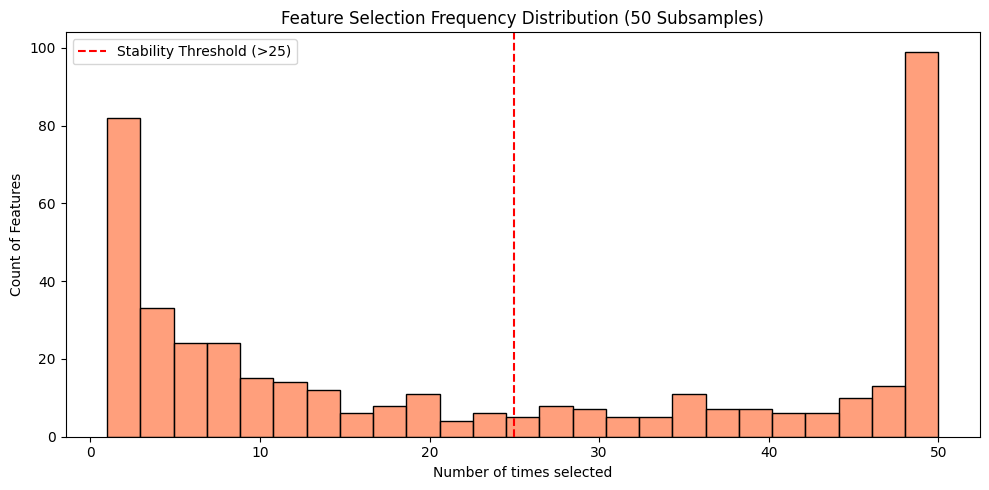

In [3]:
# %%
# Extract CpG feature names
cpg_feature_names = [n for n in feature_names if 'cg' in n]

print("Running Stability Selection...")
stable_feats, feat_counts = stability_selection(
    X_train_cpg, y_train, cpg_feature_names, 
    n_subsamples=50, subsample_fraction=0.8, top_n=200, threshold=0.5, seed=42
)

print(f"Number of stable features selected: {len(stable_feats)}")

# Deliverable: Selection-frequency distribution
plt.figure(figsize=(10, 5))
counts_series = pd.Series(feat_counts).sort_values(ascending=False)
sns.histplot(counts_series[counts_series > 0], bins=25, color='coral')
plt.axvline(x=25, color='red', linestyle='--', label='Stability Threshold (>25)')
plt.title('Feature Selection Frequency Distribution (50 Subsamples)')
plt.xlabel('Number of times selected')
plt.ylabel('Count of Features')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/task3_stability_distribution.png')
plt.show()

In [4]:
# %%
print("Evaluating K values for mRMR...")
# Convert to DataFrame as required by mrmr package
X_train_cpg_df = pd.DataFrame(X_train_cpg, columns=cpg_feature_names)
y_train_series = pd.Series(y_train)

# Test a range of K values. A good rule of thumb is to test around the number of stable features.
k_candidates = [20, 50, len(stable_feats), 150, 200]
best_k = None
best_rmse = float('inf')
mrmr_results = {}

for k in k_candidates:
    # mRMR selection
    selected_k = mrmr_regression(X=X_train_cpg_df, y=y_train_series, K=k, return_scores=True)
    mrmr_features = selected_k[0]
    
    # Evaluate using proxy model
    mask_mrmr = [name in mrmr_features for name in cpg_feature_names]
    rmse, r2 = evaluate_proxy_model(X_train_cpg, y_train, X_val_cpg, y_val, mask_mrmr)
    mrmr_results[k] = {'RMSE': rmse, 'R2': r2, 'features': mrmr_features, 'scores': selected_k[1]}
    
    print(f"mRMR K={k} -> Validation RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k

print(f"\nSelected best K for mRMR: {best_k}")
best_mrmr_features = mrmr_results[best_k]['features']
best_mrmr_scores = mrmr_results[best_k]['scores']

Evaluating K values for mRMR...


100%|██████████| 20/20 [00:00<00:00, 26.08it/s]


mRMR K=20 -> Validation RMSE: 6.4915, R2: 0.8020


100%|██████████| 50/50 [00:01<00:00, 26.75it/s]


mRMR K=50 -> Validation RMSE: 6.3084, R2: 0.8130


...

mRMR K=185 -> Validation RMSE: 5.7998, R2: 0.8419


100%|██████████| 150/150 [00:05<00:00, 27.23it/s]


mRMR K=150 -> Validation RMSE: 5.8616, R2: 0.8386


100%|██████████| 200/200 [00:07<00:00, 27.20it/s]

mRMR K=200 -> Validation RMSE: 5.7817, R2: 0.8429

Selected best K for mRMR: 200


--- Deliverable: Feature Selection Comparison Table ---


,Method,Number of Features Selected,Chosen K Justification,Validation RMSE,Validation R²
0,Stability Selection,185,Fixed threshold (>50%),6.097308,0.825308
1,mRMR,200,Lowest Validation RMSE among candidates,5.781654,0.842928



=> Method selected for Task 4: mRMR


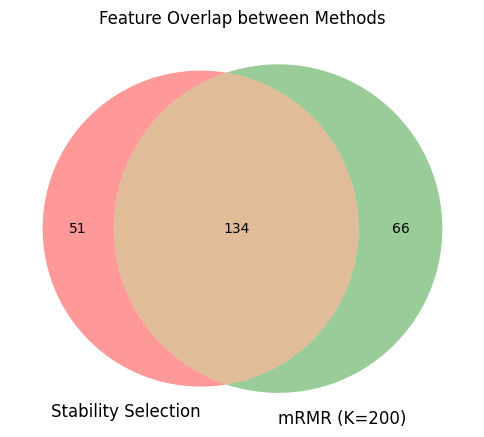


--- Deliverable: Top 10 mRMR Features by Importance Score ---


,Feature,mRMR Score
0,num__cg16867657,881.692909
1,num__cg06639320,469.042969
2,num__cg24724428,432.531641
3,num__cg07553761,343.947566
4,num__cg22454769,438.732163
5,num__cg06784991,374.431096
6,num__cg21572722,388.693807
7,num__cg24079702,352.515472
8,num__cg03032497,182.345255
9,num__cg08234504,266.185690


In [5]:
# %%
# Evaluate Stable Features
mask_stable = [name in stable_feats for name in cpg_feature_names]
stable_rmse, stable_r2 = evaluate_proxy_model(X_train_cpg, y_train, X_val_cpg, y_val, mask_stable)

# Construct Comparison Table
fs_comparison = pd.DataFrame({
    'Method': ['Stability Selection', 'mRMR'],
    'Number of Features Selected': [len(stable_feats), best_k],
    'Chosen K Justification': ['Fixed threshold (>50%)', f'Lowest Validation RMSE among candidates'],
    'Validation RMSE': [stable_rmse, best_rmse],
    'Validation R²': [stable_r2, mrmr_results[best_k]['R2']]
})

print("--- Deliverable: Feature Selection Comparison Table ---")
display(fs_comparison)

# Determine the absolute best method to carry forward to Task 4
final_best_method = 'mRMR' if best_rmse < stable_rmse else 'Stability Selection'
final_features = best_mrmr_features if best_rmse < stable_rmse else stable_feats
print(f"\n=> Method selected for Task 4: {final_best_method}")

# Deliverable: Venn Diagram
plt.figure(figsize=(6, 6))
venn2([set(stable_feats), set(best_mrmr_features)], set_labels=('Stability Selection', f'mRMR (K={best_k})'))
plt.title('Feature Overlap between Methods')
plt.savefig('../figures/task3_venn_diagram.png')
plt.show()

# Deliverable: Top 10 mRMR features
print("\n--- Deliverable: Top 10 mRMR Features by Importance Score ---")
top_10_mrmr = best_mrmr_scores.head(10).reset_index()
top_10_mrmr.columns = ['Feature', 'mRMR Score']
display(top_10_mrmr)

# Save the final selected feature names for Task 4
import pickle
with open('../data/selected_features.pkl', 'wb') as f:
    pickle.dump(final_features, f)

In [6]:
# %%
from functions import tune_regression_models
import pickle
import numpy as np

print("Loading evaluation data and selected features...")
# Load evaluation data
df_eval = load_dataset('/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/data/evaluation_data.csv')
y_eval = df_eval['age'].values

# Transform evaluation data using the already fitted preprocessor
X_eval_all = preprocessor.transform(df_eval)

# Load selected features from Task 3
with open('../data/selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

# Create masks for the selected features
mask_selected = [name in selected_features for name in feature_names]

# Subset development and evaluation sets using the selected features
X_train_selected = X_train_all[:, mask_selected]
X_val_selected = X_val_all[:, mask_selected]
X_eval_selected = X_eval_all[:, mask_selected]

# Combine Train and Val for full development refit (Task 4.1 requirement)
X_dev_selected = np.vstack((X_train_selected, X_val_selected))
y_dev = np.concatenate((y_train, y_val))

Loading evaluation data and selected features...


In [7]:
# %%
print("Running RandomizedSearchCV...")
# Tune on the development set using 5-fold CV
tuned_models = tune_regression_models(X_dev_selected, y_dev, n_iter=40, cv=5, seed=42)

print("\nRefitting best models on the full development set...")
for name, model in tuned_models.items():
    model.fit(X_dev_selected, y_dev)

Running RandomizedSearchCV...
Tuning ElasticNet...
Best CV RMSE for ElasticNet: 4.7238
Tuning SVR...
Best CV RMSE for SVR: 5.1292
Tuning Bayesian Ridge...
Best CV RMSE for Bayesian Ridge: 4.7205

Refitting best models on the full development set...


In [8]:
# %%
final_results = []
plot_data_rmse = {}
plot_data_r2 = {}
plot_data_mae = {}
plot_data_pearson = {}

for name, model in tuned_models.items():
    preds = model.predict(X_eval_selected)
    boot_metrics = bootstrap_eval(y_eval, preds, n_resamples=1000, seed=42)
    
    # Extract standard deviations
    std_rmse = np.std(boot_metrics['RMSE']['raw'])
    std_r2 = np.std(boot_metrics['R2']['raw'])
    std_mae = np.std(boot_metrics['MAE']['raw'])
    std_pearson = np.std(boot_metrics['Pearson_r']['raw'])
    
    final_results.append({
        'Model': name, 
        'Stage': 'FS+Tuned',
        'RMSE (mean)': f"{boot_metrics['RMSE']['mean']:.4f} ± {std_rmse:.4f}",
        '95% CI': f"[{boot_metrics['RMSE']['lo']:.2f}, {boot_metrics['RMSE']['hi']:.2f}]",
        'MAE': f"{boot_metrics['MAE']['mean']:.4f} ± {std_mae:.4f}",
        'R2': f"{boot_metrics['R2']['mean']:.4f} ± {std_r2:.4f}",
        'Pearson r': f"{boot_metrics['Pearson_r']['mean']:.4f} ± {std_pearson:.4f}"
    })
    
    # Store raw data for boxplots
    plot_data_rmse[name] = boot_metrics['RMSE']['raw']
    plot_data_r2[name] = boot_metrics['R2']['raw']
    plot_data_mae[name] = boot_metrics['MAE']['raw']
    plot_data_pearson[name] = boot_metrics['Pearson_r']['raw']

print("--- Deliverable: Final Tuned Models Evaluation Table ---")
final_results_df = pd.DataFrame(final_results)
display(final_results_df)

--- Deliverable: Final Tuned Models Evaluation Table ---


,Model,Stage,RMSE (mean),95% CI,MAE,R2,Pearson r
0,ElasticNet,FS+Tuned,4.9844 ± 0.7238,"[3.76, 6.55]",3.4515 ± 0.3496,0.8715 ± 0.0432,0.9360 ± 0.0213
1,SVR,FS+Tuned,5.5135 ± 0.6183,"[4.41, 6.82]",4.0812 ± 0.3672,0.8448 ± 0.0415,0.9222 ± 0.0205
2,Bayesian Ridge,FS+Tuned,4.9766 ± 0.7092,"[3.77, 6.51]",3.4868 ± 0.3451,0.8721 ± 0.0425,0.9367 ± 0.0207


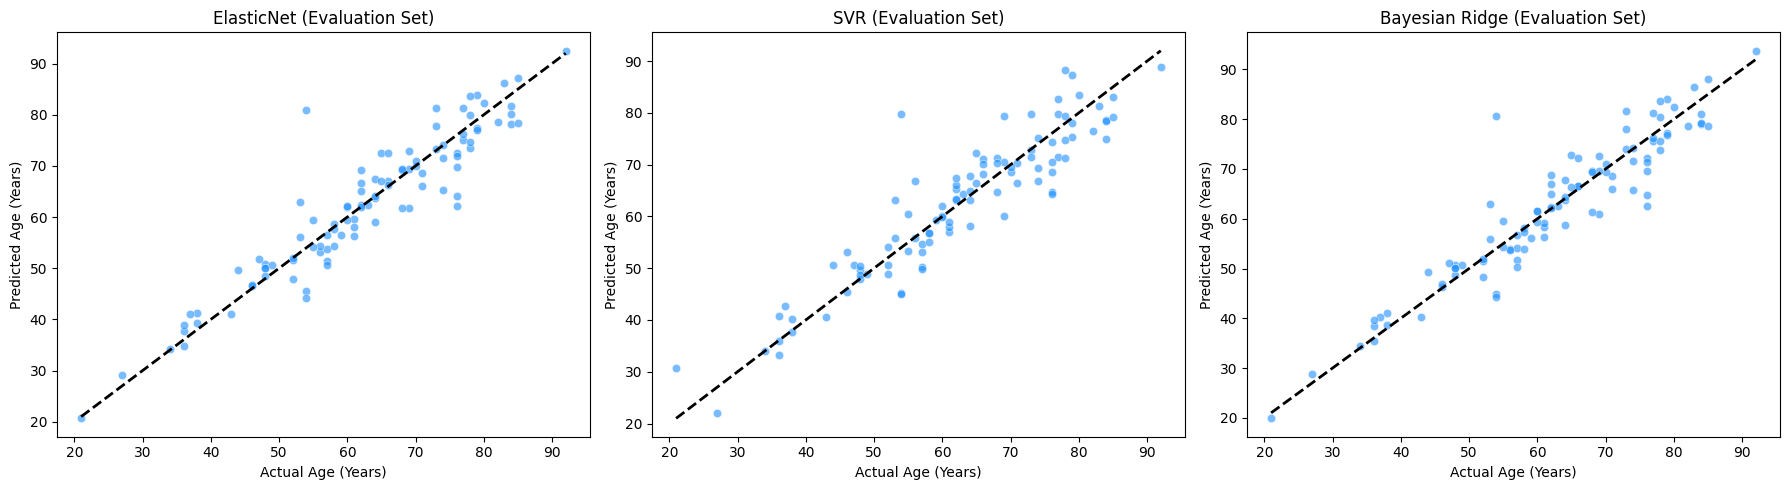

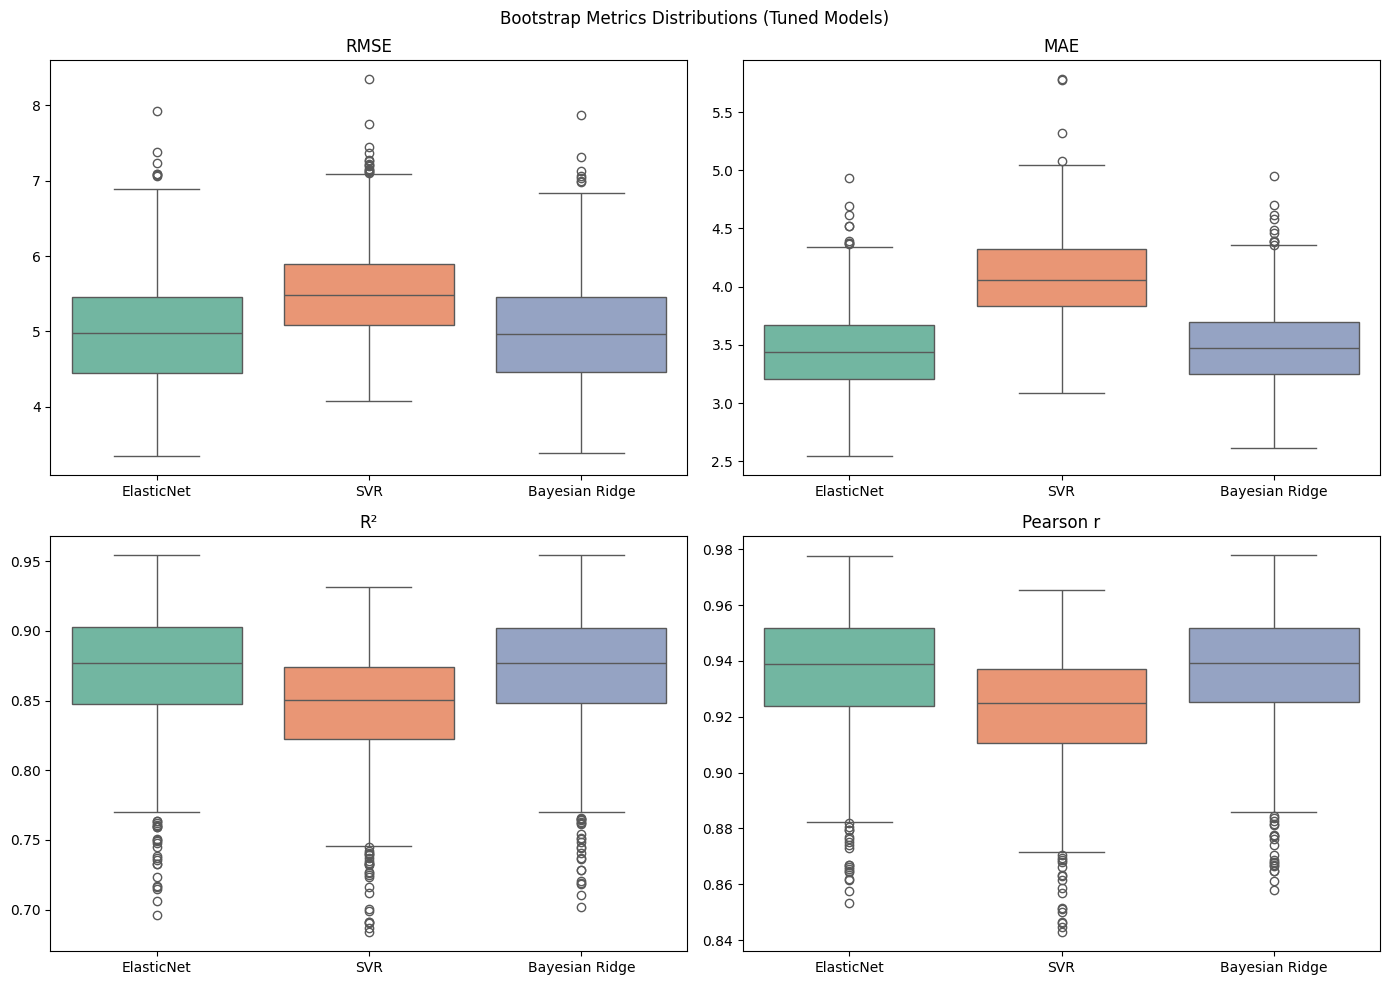

Successfully saved ElasticNet to models/best_model.pkl


In [9]:
# %%
# Deliverable: Scatter Plots of Predicted vs Actual Age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, tuned_models.items()):
    preds = model.predict(X_eval_selected)
    sns.scatterplot(x=y_eval, y=preds, ax=ax, alpha=0.6, color='dodgerblue')
    ax.plot([y_eval.min(), y_eval.max()], [y_eval.min(), y_eval.max()], 'k--', lw=2)
    ax.set_title(f'{name} (Evaluation Set)')
    ax.set_xlabel('Actual Age (Years)')
    ax.set_ylabel('Predicted Age (Years)')
plt.tight_layout()
plt.savefig('../figures/task4_scatter_plots.png', dpi=150)
plt.show()

# Deliverable: Bootstrap Boxplots for all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=pd.DataFrame(plot_data_rmse), ax=axes[0, 0], palette="Set2").set_title('RMSE')
sns.boxplot(data=pd.DataFrame(plot_data_mae), ax=axes[0, 1], palette="Set2").set_title('MAE')
sns.boxplot(data=pd.DataFrame(plot_data_r2), ax=axes[1, 0], palette="Set2").set_title('R²')
sns.boxplot(data=pd.DataFrame(plot_data_pearson), ax=axes[1, 1], palette="Set2").set_title('Pearson r')
plt.suptitle('Bootstrap Metrics Distributions (Tuned Models)')
plt.tight_layout()
plt.savefig('../figures/task4_bootstrap_boxplots.png', dpi=150)
plt.show()

# 4.3 Select Best Model
best_model_name = 'ElasticNet'
best_final_model = tuned_models[best_model_name]

# Save the final model
import os
os.makedirs('../models', exist_ok=True)
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_final_model, f)
print(f"Successfully saved {best_model_name} to models/best_model.pkl")

In [10]:
# %% Bonus A: Optuna Hyperparameter Optimization
!pip install optuna
from functions import optuna_tune_model
from sklearn.metrics import mean_squared_error

optuna_models = {}
optuna_studies = {}
model_names = ['ElasticNet', 'SVR', 'Bayesian Ridge']

print("Running Optuna Optimization...")
for name in model_names:
    print(f"Optimizing {name} with Optuna...")
    # We use X_dev_selected and y_dev from Task 4, keeping the same 40 iterations and cv=5
    best_model, study = optuna_tune_model(name, None, X_dev_selected, y_dev, n_trials=40, cv=5, seed=42)
    optuna_models[name] = best_model
    optuna_studies[name] = study

# Head-to-Head Evaluation on the Evaluation Set
bonus_a_results = []

for name in model_names:
    # RandomSearch predictions (from Task 4)
    rs_model = tuned_models[name]
    rs_preds = rs_model.predict(X_eval_selected)
    rs_rmse = np.sqrt(mean_squared_error(y_eval, rs_preds))
    
    # Optuna predictions
    op_model = optuna_models[name]
    op_preds = op_model.predict(X_eval_selected)
    op_rmse = np.sqrt(mean_squared_error(y_eval, op_preds))
    
    # Calculate delta (positive means Optuna had lower error / won)
    delta = rs_rmse - op_rmse
    winner = 'Optuna' if delta > 0 else ('RandomSearch' if delta < 0 else 'Tie')
    
    bonus_a_results.append({
        'Model': name,
        'RandomSearch RMSE': rs_rmse,
        'Optuna RMSE': op_rmse,
        'Delta': delta,
        'Winner': winner
    })

comparison_table = pd.DataFrame(bonus_a_results)
print("\n--- Deliverable: Optuna vs RandomSearch Head-to-Head Table ---")
display(comparison_table)

Running Optuna Optimization...
Optimizing ElasticNet with Optuna...
Optimizing SVR with Optuna...
Optimizing Bayesian Ridge with Optuna...

--- Deliverable: Optuna vs RandomSearch Head-to-Head Table ---


,Model,RandomSearch RMSE,Optuna RMSE,Delta,Winner
0,ElasticNet,5.010533,5.008955,1.578411e-03,Optuna
1,SVR,5.523898,5.503328,2.057060e-02,Optuna
2,Bayesian Ridge,5.002008,5.002009,-2.047867e-07,RandomSearch


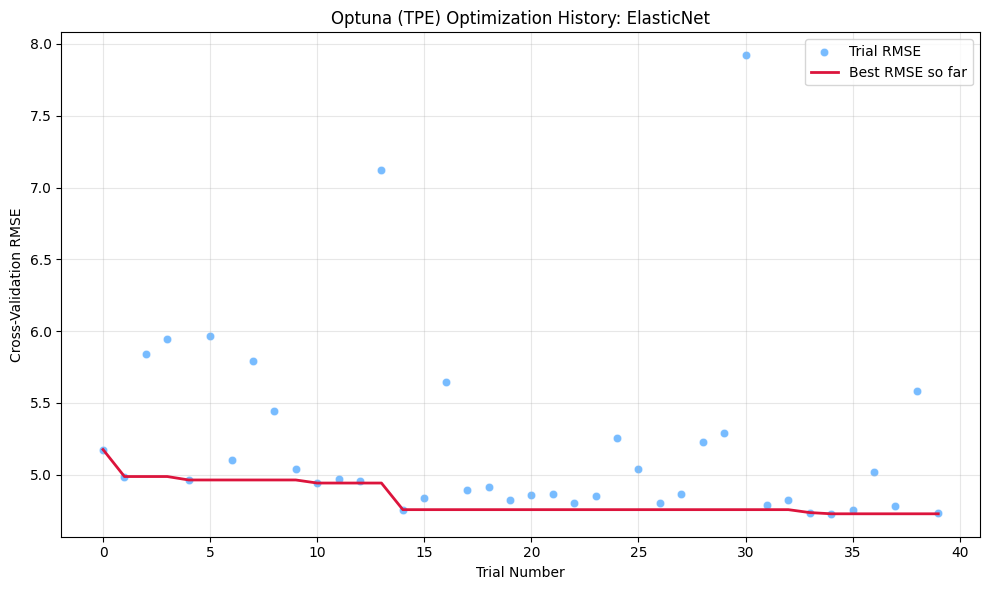

In [11]:
# %% Deliverable: Optimization History Figure
# We plot the history for ElasticNet
study_to_plot = optuna_studies['ElasticNet']
trials = study_to_plot.trials
trial_numbers = [t.number for t in trials]
trial_values = [t.value for t in trials]
best_values = [min(trial_values[:i+1]) for i in range(len(trial_values))]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=trial_numbers, y=trial_values, label='Trial RMSE', color='dodgerblue', alpha=0.6)
sns.lineplot(x=trial_numbers, y=best_values, label='Best RMSE so far', color='crimson', linewidth=2)
plt.title('Optuna (TPE) Optimization History: ElasticNet')
plt.xlabel('Trial Number')
plt.ylabel('Cross-Validation RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/bonus_a_optuna_history.png', dpi=150)
plt.show()

Setting up Bonus B: Sex Prediction...
Running mRMR for sex targeting K=200...


100%|██████████| 200/200 [00:07<00:00, 27.15it/s]


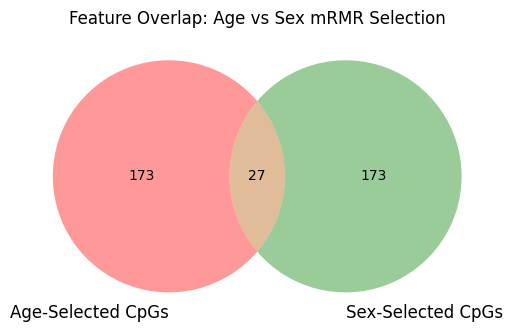

Calculating Point-Biserial Correlation...


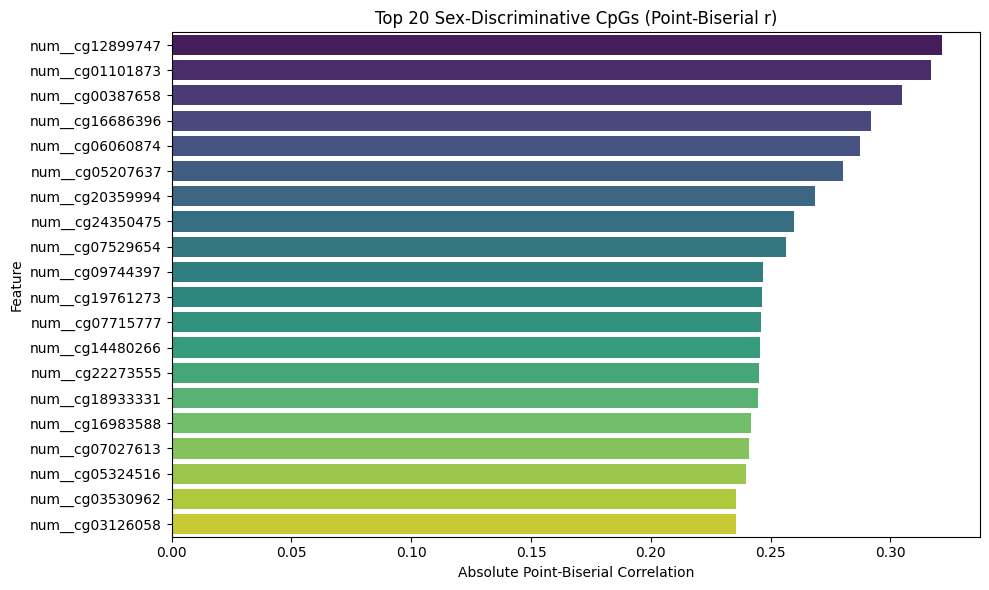

In [12]:
# %% Bonus B: Sex Prediction setup
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

print("Setting up Bonus B: Sex Prediction...")
# Encode sex column (F=0, M=1)
y_train_sex = (train_df['sex'] == 'M').astype(int).values
y_val_sex = (val_df['sex'] == 'M').astype(int).values
y_eval_sex = (df_eval['sex'] == 'M').astype(int).values

# Use mRMR with the same K chosen in Task 3, but target the sex label
print(f"Running mRMR for sex targeting K={best_k}...")
y_train_sex_series = pd.Series(y_train_sex)
sex_mrmr_output = mrmr_regression(X=X_train_cpg_df, y=y_train_sex_series, K=best_k, return_scores=True)
sex_mrmr_features = sex_mrmr_output[0]

# Deliverable: Venn diagram of feature overlap
plt.figure(figsize=(6, 6))
venn2([set(best_mrmr_features), set(sex_mrmr_features)], set_labels=('Age-Selected CpGs', 'Sex-Selected CpGs'))
plt.title('Feature Overlap: Age vs Sex mRMR Selection')
plt.savefig('../figures/bonus_b_venn_overlap.png', dpi=150)
plt.show()

# Deliverable: Bar chart of top 20 sex-discriminative CpGs by point-biserial r
print("Calculating Point-Biserial Correlation...")
pb_corrs = []
for i, feat in enumerate(cpg_feature_names):
    corr, _ = pointbiserialr(X_train_cpg[:, i], y_train_sex)
    pb_corrs.append({'Feature': feat, 'Abs_Correlation': abs(corr)})

top20_sex_cpgs = pd.DataFrame(pb_corrs).sort_values(by='Abs_Correlation', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top20_sex_cpgs, x='Abs_Correlation', y='Feature', palette='viridis')
plt.title('Top 20 Sex-Discriminative CpGs (Point-Biserial r)')
plt.xlabel('Absolute Point-Biserial Correlation')
plt.tight_layout()
plt.savefig('../figures/bonus_b_top20_cpgs.png', dpi=150)
plt.show()

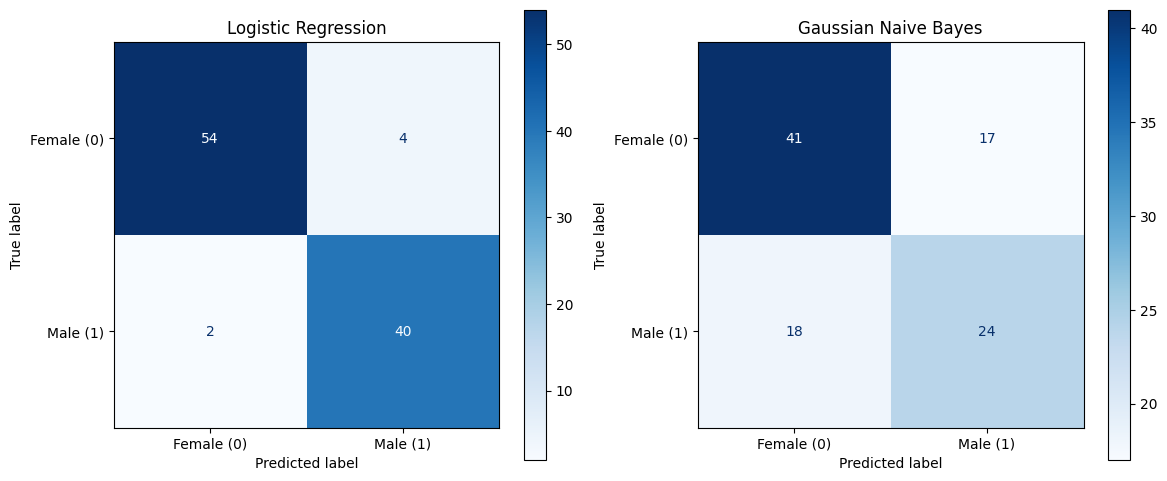

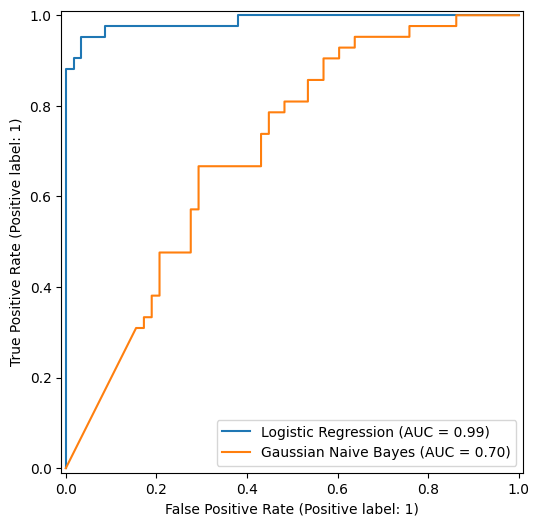

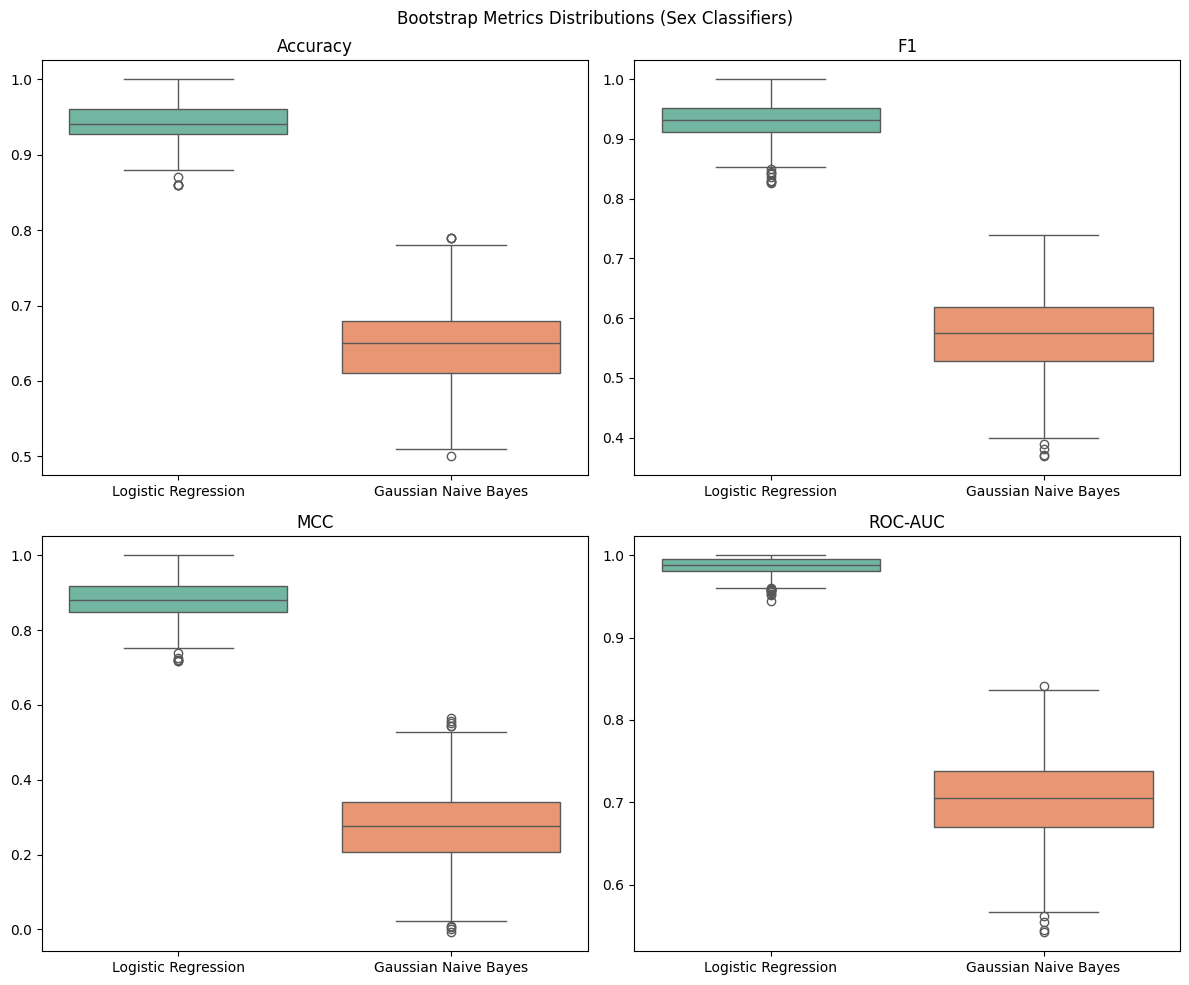


--- Deliverable: Sex Prediction Classification Table ---


,Model,Accuracy (95% CI),F1 (95% CI),MCC (95% CI),ROC-AUC (95% CI),Features
0,Logistic Regression,"0.9405 [0.89, 0.98]","0.9298 [0.87, 0.98]","0.8792 [0.78, 0.96]","0.9867 [0.96, 1.00]",200
1,Gaussian Naive Bayes,"0.6479 [0.55, 0.73]","0.5718 [0.43, 0.69]","0.2744 [0.08, 0.45]","0.7032 [0.60, 0.80]",200


In [13]:
# %% Train Classifiers and Evaluate
from functions import bootstrap_eval_class

# Create masks and subset the feature matrices for sex prediction
mask_sex = [name in sex_mrmr_features for name in feature_names]
X_train_sex_sel = X_train_all[:, mask_sex]
X_eval_sex_sel = X_eval_all[:, mask_sex]

# Initialize models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB()
}

bonus_b_results = []
plot_data_class = {'Accuracy': {}, 'F1': {}, 'MCC': {}, 'ROC-AUC': {}}

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(12, 5))
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for idx, (name, clf) in enumerate(classifiers.items()):
    clf.fit(X_train_sex_sel, y_train_sex)
    
    preds = clf.predict(X_eval_sex_sel)
    probs = clf.predict_proba(X_eval_sex_sel)[:, 1]
    
    # Bootstrap evaluation
    boot_metrics = bootstrap_eval_class(y_eval_sex, preds, probs, n_resamples=1000, seed=42)
    
    bonus_b_results.append({
        'Model': name,
        'Accuracy (95% CI)': f"{boot_metrics['Accuracy']['mean']:.4f} [{boot_metrics['Accuracy']['lo']:.2f}, {boot_metrics['Accuracy']['hi']:.2f}]",
        'F1 (95% CI)': f"{boot_metrics['F1']['mean']:.4f} [{boot_metrics['F1']['lo']:.2f}, {boot_metrics['F1']['hi']:.2f}]",
        'MCC (95% CI)': f"{boot_metrics['MCC']['mean']:.4f} [{boot_metrics['MCC']['lo']:.2f}, {boot_metrics['MCC']['hi']:.2f}]",
        'ROC-AUC (95% CI)': f"{boot_metrics['ROC-AUC']['mean']:.4f} [{boot_metrics['ROC-AUC']['lo']:.2f}, {boot_metrics['ROC-AUC']['hi']:.2f}]",
        'Features': best_k
    })
    
    # Store raw data for boxplots
    for metric in plot_data_class.keys():
        plot_data_class[metric][name] = boot_metrics[metric]['raw']
        
    # Deliverable: Confusion Matrices
    ConfusionMatrixDisplay.from_predictions(y_eval_sex, preds, display_labels=['Female (0)', 'Male (1)'], ax=axes_cm[idx], cmap='Blues')
    axes_cm[idx].set_title(f'{name}')
    
    # Deliverable: ROC Curves
    RocCurveDisplay.from_predictions(y_eval_sex, probs, name=name, ax=ax_roc)

axes_cm[0].figure.tight_layout()
axes_cm[0].figure.savefig('../figures/bonus_b_confusion_matrices.png', dpi=150)
plt.show()

ax_roc.set_title('ROC Curves (Evaluation Set)')
ax_roc.figure.savefig('../figures/bonus_b_roc_curves.png', dpi=150)
plt.show()

# Deliverable: Bootstrap Boxplots
fig_box, axes_box = plt.subplots(2, 2, figsize=(12, 10))
metrics_to_plot = list(plot_data_class.keys())
for i, ax in enumerate(axes_box.flatten()):
    sns.boxplot(data=pd.DataFrame(plot_data_class[metrics_to_plot[i]]), ax=ax, palette='Set2')
    ax.set_title(metrics_to_plot[i])
plt.suptitle('Bootstrap Metrics Distributions (Sex Classifiers)')
plt.tight_layout()
plt.savefig('../figures/bonus_b_bootstrap_boxplots.png', dpi=150)
plt.show()

print("\n--- Deliverable: Sex Prediction Classification Table ---")
display(pd.DataFrame(bonus_b_results))